# Разработка A/B-тестирования и анализ результатов

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций для пользователей развлекательного приложения с функцией «бесконечной» ленты, который, по их мнению, будет показывать более интересный контент для каждого пользователя. 

Необходимо рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

## Описание данных

Таблицы:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. 

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. 

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. 

У таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).



### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных

In [1]:
import pandas as pd

sessions_history = pd.read_csv('https://ссылка_sessions_project_history.csv')

# Выводим первые 5 строк датафрейма
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


In [2]:
# Выводим данные о датафреме
sessions_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            435924 non-null  object
 1   session_id         435924 non-null  object
 2   session_date       435924 non-null  object
 3   session_start_ts   435924 non-null  object
 4   install_date       435924 non-null  object
 5   session_number     435924 non-null  int64 
 6   registration_flag  435924 non-null  int64 
 7   page_counter       435924 non-null  int64 
 8   region             435924 non-null  object
 9   device             435924 non-null  object
dtypes: int64(3), object(7)
memory usage: 33.3+ MB


#### 1.2. Знакомство с данными


In [3]:
# Рассчитываем количество уникальных сессий для каждого пользователя
sessions_history.groupby('user_id')['session_id'].count().sort_values(ascending=False)

user_id
10E0DEFC1ABDBBE0    10
6A73CB5566BB494D    10
8A60431A825D035B     9
D11541BAC141FB94     9
5BCFE7C4DCC148E9     9
                    ..
1DF13BB1953B3497     1
628502A3CE7E0A3C     1
1DEEF40DEFBD0C65     1
AC08479B7472C628     1
8A0882B6715D9EE5     1
Name: session_id, Length: 134039, dtype: int64

In [4]:
# Выведем данные датафрейма для пользователя с маскимальным количеством сессий
sessions_history.loc[sessions_history['user_id'] == '10E0DEFC1ABDBBE0']

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


По данным таблицы можно отметить, что дата установки приложения `install_date` совпадает с датой первой сессии `session_start_ts` (что логично), пользоваться приложением можно без регистрации (поле `registration_flag` == 0).

#### 1.3. Анализ числа регистраций

In [5]:
# Рассчитываем число уникальных пользователей для каждого дня
unique_users_by_day = sessions_history.groupby('session_date')['user_id'].nunique()

In [6]:
# Рассчитываем число зарегистрированных пользователей для каждого дня
regestered_users_by_day = sessions_history[sessions_history['registration_flag'] == 1].groupby('session_date')['user_id'].nunique()

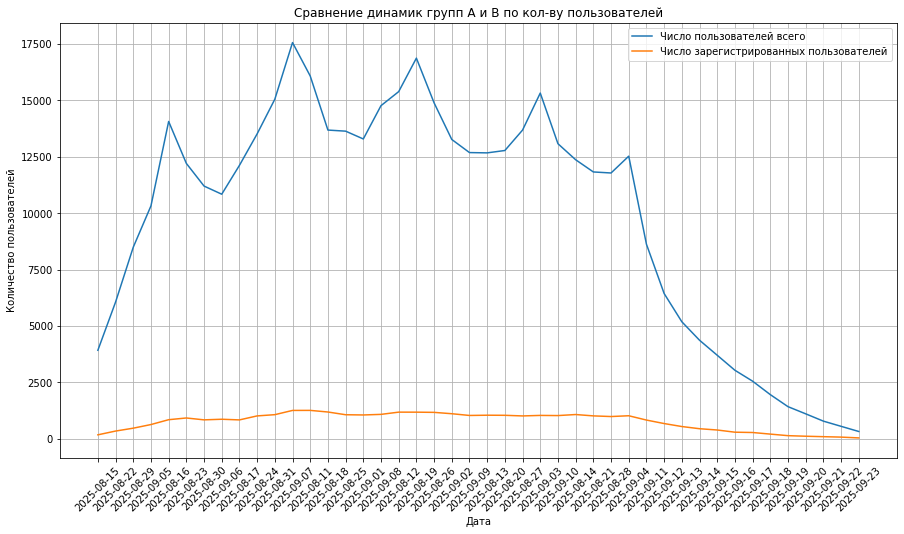

In [7]:
# Строим графики общего числа пользователей и общего числа зарегистрированных пользователей по дням

import matplotlib.pyplot as plt

x = sessions_history['session_date'].unique()
y_a = unique_users_by_day
y_b = regestered_users_by_day

plt.figure(figsize=(15, 8))
plt.plot(x, y_a, label ='Число пользователей всего')
plt.plot(x, y_b,label ='Число зарегистрированных пользователей')

plt.xlabel("Дата")
plt.ylabel("Количество пользователей")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.title('Сравнение динамик групп A и B по кол-ву пользователей')
plt.show()

В начале рассматриваемого периода динамика общего числа пользователей положительна (рост примерно от 3500 до 13500 пользователей), далее она носит изменчивый харатер: растет и снижается (всего таких периодов 4, маскимальное количество пользователей в этот период 17500, минимальное - примерно 11000), в конце периода наблюдаем динамику существенного сокращения количества пользователей (с 12500 до примерно 500 пользователей). 

Динамика показателя зарегистрированных пользователей существенно ниже и характеризуются слабой восходящей, а длее отрицательной динамикой стремящейся к нулю, в целом слабо подвержена изменениям (изменения в диапазоне от околонулевого значения до примерно 1250 пользователей в день).

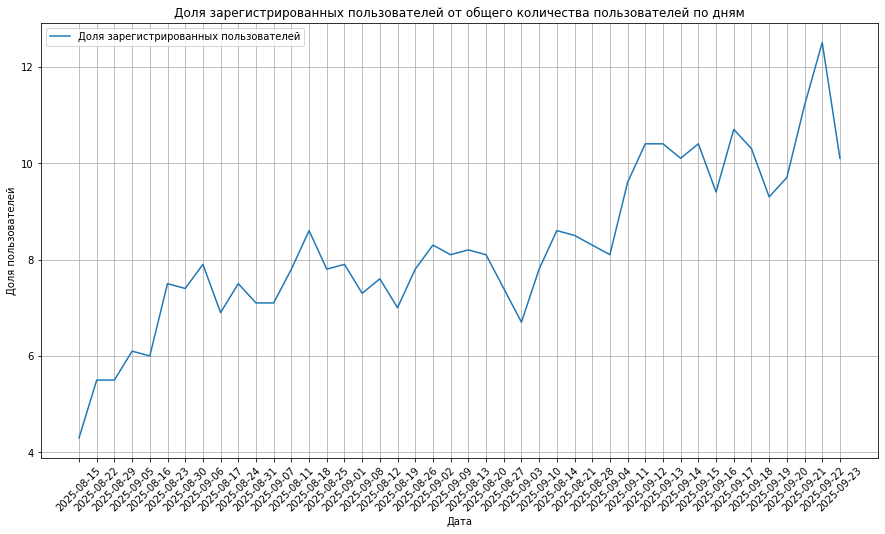

In [8]:
# Доля зарегистрированных пользователей по дням
fraction_regestered_users = round(regestered_users_by_day*100/unique_users_by_day, 1)

# Строим линейный график долей зарегистрированных пользователей по дням
x = sessions_history['session_date'].unique()
y = fraction_regestered_users

plt.figure(figsize=(15, 8))
plt.plot(x, y, label ='Доля зарегистрированных пользователей')

plt.xlabel("Дата")
plt.ylabel("Доля пользователей")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.title('Доля зарегистрированных пользователей от общего количества пользователей по дням')
plt.show()

Доля зарегистрированных пользователей от общего их количества в целом харатеризуется положительной динамикой, достигая пика примерно в 12,2% к концу периода, после чего наблюдается существенное падение показателя на 2 процентных пункта - примерно до 10,2%.

#### 1.4. Анализ числа просмотренных страниц

In [9]:
# Найдем количество сессий для каждого значения просмотренных страниц
sessions_history.groupby('page_counter')['session_id'].count()

page_counter
1     29160
2    105536
3    166690
4    105569
5     26288
6      2589
7        92
Name: session_id, dtype: int64

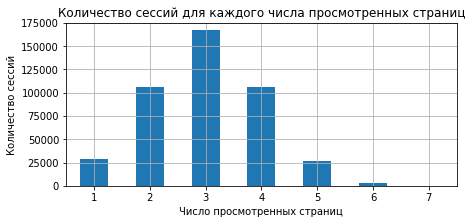

In [10]:
# Строим столбчатую диаграмму

plt.figure(figsize=(7, 3))

sessions_history.groupby('page_counter')['session_id'].count().plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Количество сессий для каждого числа просмотренных страниц'
)

# Настраиваем оформление графика
plt.xlabel('Число просмотренных страниц')
plt.ylabel('Количество сессий')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Чаще всего пользователи просмтривают 3 страницы (167тыс. сессий), 2 или 4 страницы (по 106 тыс.сессий) за одну сессию.

#### 1.5. Доля пользователей, просмотревших более четырёх страниц

In [11]:
# Создаем новый столбец
def create_column(x):
    if x >= 4:
        return 1
    return 0

sessions_history['good_session'] = sessions_history['page_counter'].apply(create_column)

In [12]:
# Находим долю успешных сессий по дням
fraction_good_session = round(sessions_history.groupby('session_date')['good_session'].mean()*100, 1)

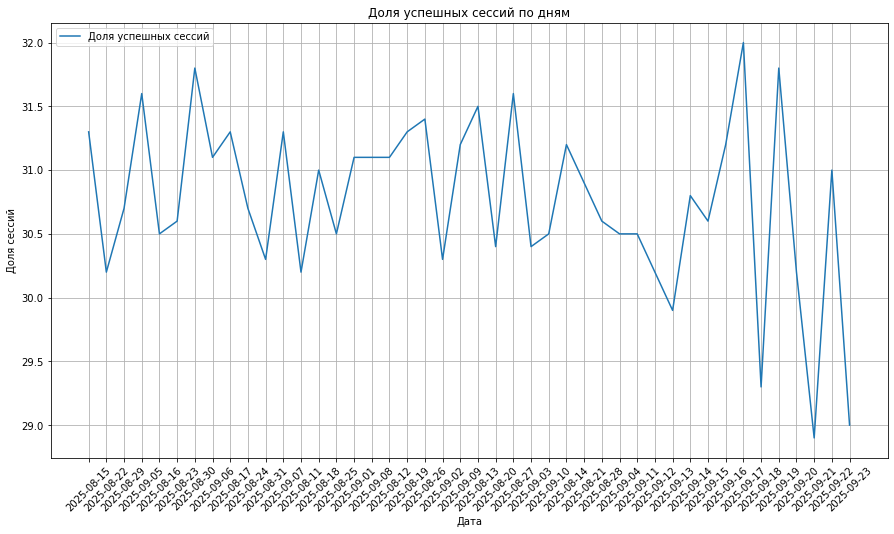

In [13]:
# Строим линейный график доли успешных сессий по дням
x = sessions_history['session_date'].unique()
y = fraction_good_session

plt.figure(figsize=(15, 8))
plt.plot(x, y, label ='Доля успешных сессий')

plt.xlabel("Дата")
plt.ylabel("Доля сессий")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.title('Доля успешных сессий по дням')
plt.show()

Динамика изменения доли успешных сессий чаще находится в диапазоне от 30% до 32%, к концу периода динамика отрицательна - доля успешных сессий сокращается до 29%.

### 2. Подготовка к тесту


#### 2.1. Расчёт размера выборки

In [14]:
from statsmodels.stats.power import NormalIndPower

# Задаём параметры
alpha = 0.05  # Уровень значимости
beta =  0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
mde = 0.03  # Минимальный детектируемый эффект

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Рассчитываем размер выборки
sample_size = power_analysis.solve_power(
    effect_size = mde,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 17441


#### 2.1. Расчёт длительности A/B-теста


In [15]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = round((sessions_history.groupby('session_date')['user_id'].nunique()).mean())

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size*2/avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907 пользователей в день составит 4 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей


In [16]:
sessions_test_part = pd.read_csv('ссылка_sessions_project_test_part.csv')

In [17]:
# Рассчитываем количество уникальных пользователей в каждой из экспериментальных групп 
A = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'].nunique()
B = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'].nunique()

display(A, B)

1477

1466

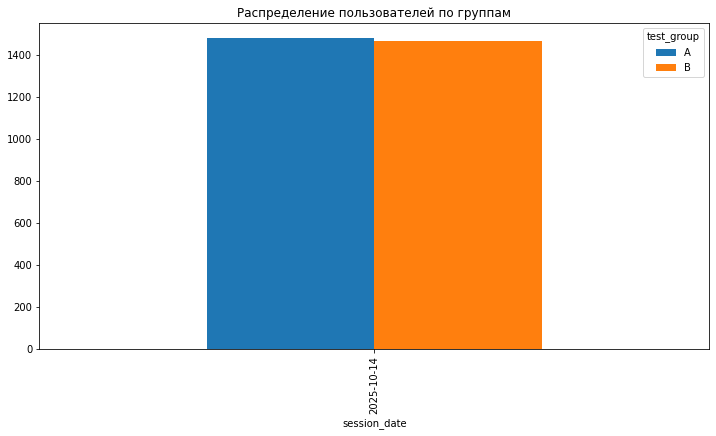

In [18]:
# График распределения пользователей по группам
daily_users = sessions_test_part.groupby(['session_date', 'test_group'])['user_id'].nunique().unstack()
daily_users.plot(kind='bar', figsize=(12, 6))
plt.title('Распределение пользователей по группам')
plt.show()

In [19]:
# Рассчитываем процентную разницу в количестве пользователей в группах A и B
P = round(100*abs(A - B)/A, 2)
display(P)

0.74

В группах А и В сопоставимое примерно равное количество пользователей (1477 и 1466 человек соответственно), разница между количеством пользователей менее 1%, что отвечает условиям эксперимента.

#### 3.2. Проверка пересечений пользователей


In [20]:
group_A = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id']
group_B = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id']

intersection = list(set(group_A) & set(group_B))
print(intersection) 

[]


Видим, что группы независимы, пересекающихся данных нет.

#### 3.3. Равномерность разделения пользователей по устройствам


In [21]:
# Создадим датафрейм пользователей группы А, очищенный от дубликатов по полям user_id и device,  
# (оставляем уникальных пользователей группы А)
df_A = sessions_test_part[sessions_test_part['test_group'] == 'A'].drop_duplicates(['user_id', 'device'])

In [22]:
# Создадим датафрейм пользователей группы В, очищенный от дубликатов по полям user_id и device,  
# (оставляем уникальных пользователей группы В)
df_B = sessions_test_part[sessions_test_part['test_group'] == 'B'].drop_duplicates(['user_id', 'device'])

In [23]:
# Находим долю каждого типа устройства для пользователей из группы A
devices_group_A = round(df_A['device'].value_counts()*100 \
/df_A.shape[0], 1)

In [24]:
# Находим долю каждого типа устройства для пользователей из группы B
devices_group_B = round(df_B['device'].value_counts()*100 \
/df_B.shape[0], 1)

In [25]:
# Объединим полученные данные в датафрейм
df = pd.concat([devices_group_A.to_frame(), devices_group_B.to_frame()], axis=1) 

# Переименуем названия колонок
df.columns = ['Группа_А','Группа_B']

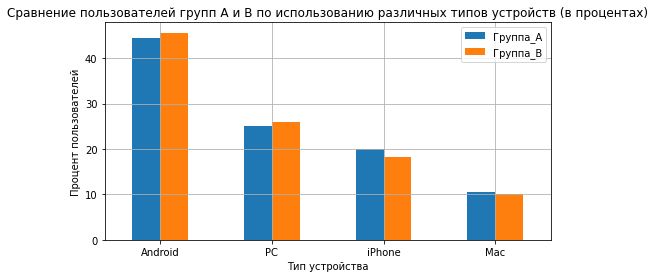

In [26]:
# Построим диаграмму сравнения пользователей различных девайсов
df.plot(kind='bar',
        title=f'Сравнение пользователей групп A и B по использованию различных типов устройств (в процентах)',
        legend=True,
        ylabel='Процент пользователей',
        xlabel='Тип устройства',
        rot=0,
        figsize=(8, 4))
plt.grid()

# Выводим график
plt.show()

Видим, что показатели процентов использования отдельных типов устройств в группах А и В отличаются незначительно, следовательно, группы сопоставимы по данной категориальной переменной.

#### 3.4. Равномерность распределения пользователей по регионам


In [27]:
# Создадим датафрейм пользователей группы А, очищенный от дубликатов по полю user_id 
df_A_unique = sessions_test_part[sessions_test_part['test_group'] == 'A'].drop_duplicates(['user_id'])

In [28]:
# Создадим датафрейм пользователей группы В, очищенный от дубликатов по полю user_id 
df_B_unique = sessions_test_part[sessions_test_part['test_group'] == 'B'].drop_duplicates(['user_id'])

In [29]:
# Находим долю каждого региона для пользователей из группы A
region_group_A = round(df_A_unique['region'].value_counts()*100 \
/df_A_unique.shape[0], 1)

In [30]:
# Находим долю каждого региона для пользователей из группы B
region_group_B = round(df_B_unique['region'].value_counts()*100 \
/df_B_unique.shape[0], 1)

In [31]:
# Объединим полученные данные в датафрейм
df_region = pd.concat([region_group_A.to_frame(), region_group_B.to_frame()], axis=1) 

# Переименуем названия колонок
df_region.columns = ['Группа_А','Группа_B']

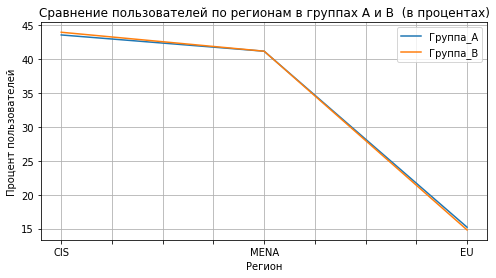

In [32]:
# Построим диаграмму сравнения пользователей различных регионов
df_region.plot(kind='line',
        title=f'Сравнение пользователей по регионам в группах A и B  (в процентах)',
        legend=True,
        ylabel='Процент пользователей',
        xlabel='Регион',
        rot=0,
        figsize=(8, 4))
plt.grid()

# Выводим график
plt.show()

Показатели процента пользователей различных регионов в группах А и В отличаются незначительно, по данной категориальной переменной группы сопоставимы.

#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста можем сформулировать следующие выводы:

- Различие в количестве пользователей в двух группах составляет менее 1%, что допустимо, так, в группе А - 1477 пользователей, в группе В - 1466 пользователей.

- Выборки  являются независимыми, пересечение пользователей из тестовой и контрольной групп обнаружено не было.

- Сохраняется равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Из проведенного анализа, можем сделать заключение, что A/B-тест проходит корректно.

### 4. Проверка результатов A/B-теста



#### 4.1. Получение результатов теста и подсчёт основной метрики


In [33]:
sessions_test = pd.read_csv('https://ссылка_sessions_project_test.csv')

In [34]:
# Создаем новый столбец
def create_column(x):
    if x >= 4:
        return 1
    return 0

sessions_test['good_session'] = sessions_test['page_counter'].apply(create_column)

#### 4.2. Проверка корректности результатов теста



In [35]:
# Рассчитываем количество уникальных сессий для каждого дня в группе А
nunique_session_A = sessions_test[sessions_test['test_group'] == 'A'].groupby('session_date')['session_id'].nunique()

In [36]:
# Рассчитываем количество уникальных сессий для каждого дня в группе B
nunique_session_B = sessions_test[sessions_test['test_group'] == 'B'].groupby('session_date')['session_id'].nunique()

In [37]:
# Проверяем стат.значимость различий количества уникальных дневных сессий в двух выборках
from scipy.stats import ttest_ind

test_result = ttest_ind(
    nunique_session_A,
    nunique_session_B,
    alternative='two-sided'
)

alpha = 0.05

if test_result.pvalue > alpha:
    print(f'pvalue={test_result.pvalue} > {alpha}')
    print('Не получилось отвергнуть нулевую гипотезу')
else:
    print(f'pvalue={test_result.pvalue} < {alpha}')
    print('Отвергаем нулевую гипотезу')

pvalue=0.938219304859116 > 0.05
Не получилось отвергнуть нулевую гипотезу


Значение pvalue больше уровня статистической значимости, т.е. вероятность того, что наблюдаемые изменения могли быть получены случайно (при верной нулевой гипотезе) больше, чем вероятность отказа от нулевой гипотезы. Следовательно, гипотеза о том, что количество уникальных дневных сессий в двух выборках не различается или различия не статистически значимы, подтверждается.

#### 4.3. Сравнение доли успешных сессий


In [38]:
# Находим долю успешных сессий для выборки А
fraction_good_session_A = round(sessions_test[sessions_test['test_group'] == 'A']['good_session'].mean(), 4)

# Находим долю успешных сессий для выборки B
fraction_good_session_B = round(sessions_test[sessions_test['test_group'] == 'B']['good_session'].mean(), 4)

# Находим разницу долей успешных сессий между выборками А и В
differense = round(fraction_good_session_B - fraction_good_session_A, 4)

fraction_good_session_A, fraction_good_session_B, differense

(0.3077, 0.3183, 0.0106)

Можем сделать вывод, что количество успешных сессий в тестовой выборке (в группе В) на 1,06% выше, чем в контрольной (в группе А).

#### 4.4. Насколько статистически значимо изменение ключевой метрики


In [39]:
# Выведем значение p-value Z-теста пропорций

from statsmodels.stats.proportion import proportions_ztest

n_a = sessions_test[sessions_test['test_group'] == 'A'].shape[0] # Размер группы А

n_b = sessions_test[sessions_test['test_group'] == 'B'].shape[0] # Размер группы В

m_a = sessions_test[ #  кол-во успехов в группе A
    (sessions_test.test_group=='A')&(sessions_test.good_session==1)
].shape[0] 

m_b = sessions_test[ #  количество успехов в группе B
     (sessions_test.test_group=='B')&(sessions_test.good_session==1)
].shape[0]

p_a, p_b = m_a/n_a, m_b/n_b # посчитайте доли успехов для каждой группы: A и B

# проверяем предпосылку о достаточном количестве данных
if (p_a*n_a > 10)and((1-p_a)*n_a > 10)and(p_b*n_b > 10)and((1-p_b)*n_b > 10): 
    
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')

alpha = 0.05 ##  уровень значимости


stat_ztest, p_value_ztest = proportions_ztest( # проведим Z-тест пропорций
	[m_a, m_b],
	[n_a, n_b],
	alternative='smaller'
)

print(f'pvalue={p_value_ztest}') # выведите полученное p-value 

if p_value_ztest > alpha:
    print('Нулевая гипотеза находит подтверждение!')
else:
    print('Нулевая гипотеза не находит подтверждения!')

Предпосылка о достаточном количестве данных выполняется!
pvalue=0.0001574739988036123
Нулевая гипотеза не находит подтверждения!


Исходя из результатов проведенного статистического теста можем сделать вывод о том, что альтернативная гипотеза находит подтверждение,  т.е. количество успешных сессий возрастет после введения новшеств.

#### 4.5. Вывод по результатам A/B-эксперимента

Выводы о результатах проведенного экспериманта:

Цель эксперимента - выявить влияние внедрения нового алгоритма рекомендаций на интерес пользователей к контенту (интерес пользователей выражается количеством просмотренных страниц: успешной считается сессия, в течение которой просмотренно 4 и более страницы). Ключевая метрика - доля успешных сессий.
- Нулевая гипотеза: в результате внедрения нового алгоритма рекомендаций, доля успешных сессий в тестовой и контрольной группах не изменится.
- Альтернативная гипотеза: в результате внедрения нового алгоритма рекомендаций, доля успешных сессий возрастет в тестовой группе по сравнению с контрольной.

Количество задействованных пользователей в контрольной группе - 1477, в тестовой группе - 1466, длительность эксперимента - 20 дней.

В результате внедрения нового алгоритма рекомендаций, ключевая метрика (доля успешных сессий) возросла в тестовой группе по сравнению с контрольной на 1,1 процентных пункта.

Значение p-value при оценке статистической значимости выявленного эффекта составило pvalue=0.0001574739988036123, что меньше уровня статистической значимости (0,05) и позволяет сделать вывод о том, что альтернативная гипотеза находит подтверждение, т.е. количество успешных сессий возрастет после  внедрения нового алгоритма рекомендаций, следовательно, данную практику можно рекомендовать внедрить в приложение.